# 2. Analysis: 시계열 분석 + 다수준 로지스틱 회귀

| 항목 | 내용 |
|------|------|
| **입력** | `output/pre_output/analytic_sample.csv` (1_preprocess 출력) |
| **출력** | `output/analysis_output/` (테이블 CSV, 그림 PNG) |
| **분석** | (A) 시간 추세 (B) Survey-weighted GLM (C) Sensitivity |

In [1]:
# ══════════════════════════════════════════════════════════════
# Cell 1 — 환경 설정 + 데이터 로드 (Colab/Local portable + verbose)
# ══════════════════════════════════════════════════════════════
import os, sys, time
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha'
    ENV = 'Colab'
except ImportError:
    BASE = os.path.expanduser(
        '~/Library/CloudStorage/GoogleDrive-y3korea@gmail.com/'
        '내 드라이브/완석_구글자료/연구자료/20260313_kosha')
    ENV = 'Local'
assert os.path.exists(BASE), f'❌ BASE not found: {BASE}'
print(f'[ENV] {ENV}')
print(f'[BASE] {BASE}')

import pandas as pd, numpy as np, warnings
from datetime import datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
warnings.filterwarnings('ignore')

PRE_DIR  = os.path.join(BASE, 'Code_kosha', '1_code', 'output', 'pre_output')
OUT_BASE = os.path.join(BASE, 'Code_kosha', '1_code', 'output', 'analysis_output')
os.makedirs(OUT_BASE, exist_ok=True)

# ── Sanity checks ──
assert os.path.isdir(PRE_DIR), f'❌ PRE_DIR NOT FOUND: {PRE_DIR}'
assert os.path.isdir(OUT_BASE), f'❌ OUT_BASE NOT FOUND: {OUT_BASE}'
print(f'[PRE_DIR  ✓] {PRE_DIR}')
print(f'[OUT_BASE ✓] {OUT_BASE}')

# ── 입력 파일 검증 (1_preprocess.ipynb 산출물) ──
input_csv = os.path.join(PRE_DIR, 'analytic_sample.csv')
assert os.path.exists(input_csv), (
    f'❌ INPUT NOT FOUND: {input_csv}\n'
    f'   → 1_preprocess.ipynb를 먼저 실행해서 analytic_sample.csv를 생성하세요.')
mt = datetime.fromtimestamp(os.path.getmtime(input_csv))
sz_in = os.path.getsize(input_csv) / 1024 / 1024
print(f'[INPUT ✓] {input_csv}')
print(f'  Size: {sz_in:.1f} MB, Modified: {mt}')

# ── 실행할 때마다 타임스탬프 폴더 생성 ──
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
OUT_DIR = os.path.join(OUT_BASE, f'run_{timestamp}')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'\n[RUN ✓] {OUT_DIR}')

# ── Drive WRITE 권한 smoke test (RUNDIR 위에서 직접) ──
test_path = os.path.join(OUT_DIR, '_write_test.tmp')
try:
    t0 = time.time()
    with open(test_path, 'w') as f:
        f.write('write_test_ok')
    with open(test_path) as f:
        assert f.read() == 'write_test_ok'
    os.remove(test_path)
    print(f'[WRITE TEST ✓] OUT_DIR is writable ({(time.time()-t0)*1000:.0f} ms)')
except Exception as e:
    print(f'[WRITE TEST ✗] {type(e).__name__}: {e}')
    raise

# ── 데이터 로드 ──
# ── Colab/Jupyter display helpers + 300 dpi 강제 ──
import matplotlib.pyplot as _plt_setup
_plt_setup.rcParams['savefig.dpi'] = 300
_plt_setup.rcParams['savefig.bbox'] = 'tight'
_plt_setup.rcParams['figure.dpi']  = 100  # 화면 표시용 (저장은 300)
try:
    from IPython.display import display, Markdown, HTML
    def show_md(text):
        display(Markdown(text))
    IN_NOTEBOOK = True
except ImportError:
    def display(x): print(x)
    def show_md(text): print(text)
    IN_NOTEBOOK = False

df = pd.read_csv(input_csv, encoding='utf-8-sig')
YEARS = {2:2010, 3:2011, 4:2014, 5:2017, 6:2020, 7:2023}
print(f'\n로드 완료: N={len(df):,} × {len(df.columns)} cols')

# 기존 실행 목록 출력
prev_runs = sorted([d for d in os.listdir(OUT_BASE)
                    if os.path.isdir(os.path.join(OUT_BASE, d)) and d.startswith('run_')])
if len(prev_runs) > 1:
    print(f'기존 run 폴더 ({len(prev_runs)-1}개):')
    for r in prev_runs[-5:]:
        marker = '← 이번 실행' if r == f'run_{timestamp}' else ''
        print(f'  • {r}  {marker}')


Mounted at /content/drive
[ENV] Colab
[BASE] /content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha
[PRE_DIR  ✓] /content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/Code_kosha/1_code/output/pre_output
[OUT_BASE ✓] /content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/Code_kosha/1_code/output/analysis_output
[INPUT ✓] /content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/Code_kosha/1_code/output/pre_output/analytic_sample.csv
  Size: 31.5 MB, Modified: 2026-05-10 07:46:00

[RUN ✓] /content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/Code_kosha/1_code/output/analysis_output/run_20260524_0444
[WRITE TEST ✓] OUT_DIR is writable (15 ms)

로드 완료: N=119,912 × 57 cols
기존 run 폴더 (3개):
  • run_20260510_0746  
  • run_20260510_1052  
  • run_20260524_0444  ← 이번 실행
  • run_20260524_0847  


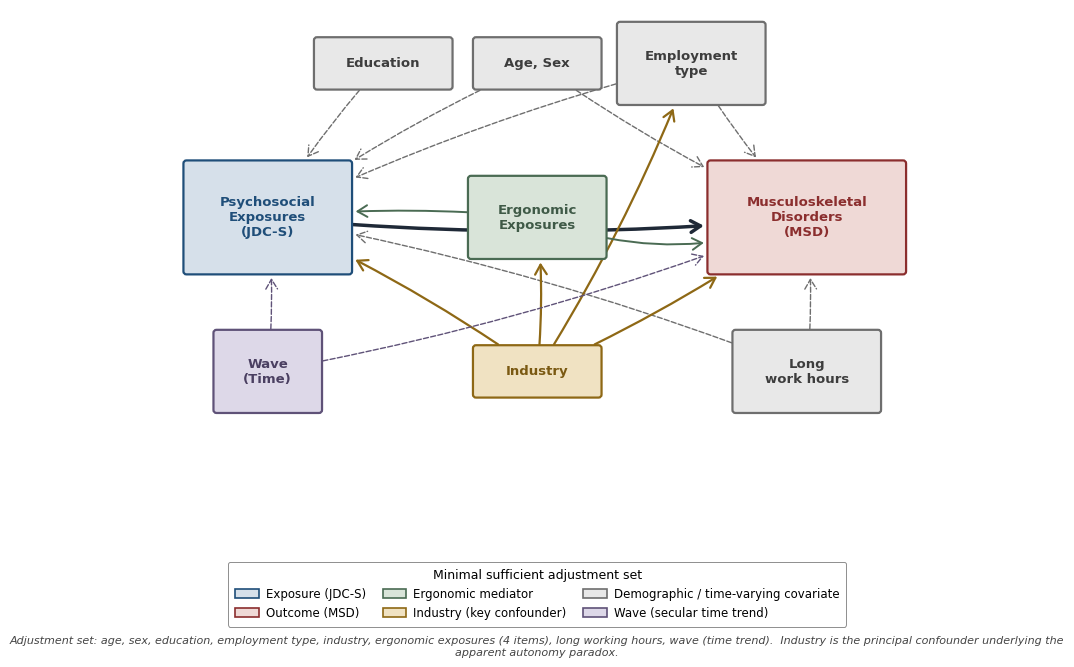

저장: fig_dag.png + fig_dag.pdf  (300 dpi PNG + vector PDF)


In [2]:
# ══════════════════════════════════════════════════════════════
# Cell 1b — DAG (Directed Acyclic Graph) — publication-grade
# ══════════════════════════════════════════════════════════════
# Design notes (Lancet/BMJ-compatible):
# 1. Desaturated palette — 2 emphasis (navy/crimson), 1 accent (amber for key
#    confounder), and supporting forest/lavender/gray. CVD-safe (Wong 2011),
#    legible in B&W print.
# 2. Open arrowheads ('->') with explicit head_length/head_width — line stem
#    and arrow head do not overlap at boundary.
# 3. patchA/patchB clipping → arrows terminate exactly at box edge.
# 4. Main causal path PSY→MSD: solid near-black, lw=2.5 (relationship of interest).
# 5. Legend + footer caption placed BELOW the axes (no overlap).
# ══════════════════════════════════════════════════════════════

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ── Professional palette ──
PAL = {
    'exposure':   {'fill': '#D6E0EA', 'edge': '#1F4E79', 'text': '#1F4E79'},  # navy
    'outcome':    {'fill': '#EFD9D6', 'edge': '#8B2E2E', 'text': '#8B2E2E'},  # crimson
    'mediator':   {'fill': '#D9E4D9', 'edge': '#4A6B53', 'text': '#3F5A47'},  # forest
    'confounder': {'fill': '#E8E8E8', 'edge': '#6E6E6E', 'text': '#3D3D3D'},  # neutral gray
    'key_conf':   {'fill': '#F0E2C2', 'edge': '#8E6815', 'text': '#7A5912'},  # amber (key)
    'time':       {'fill': '#DDD8E8', 'edge': '#5F5278', 'text': '#4A3F61'},  # lavender
}

fig, ax = plt.subplots(figsize=(11, 7))                # tighter aspect ratio
ax.set_xlim(-0.3, 10.3)
ax.set_ylim(2.7, 8.7)                                  # axes spans only the DAG region
ax.set_aspect('equal')
ax.axis('off')
# Title is provided by the manuscript caption; figure itself has no embedded title

# ── Nodes ──
nodes = {
    'PSY':    (1.5, 6.0, 'Psychosocial\nExposures\n(JDC-S)', 'exposure'),
    'MSD':    (8.5, 6.0, 'Musculoskeletal\nDisorders\n(MSD)', 'outcome'),
    'SES':    (3.0, 8.0, 'Education',                         'confounder'),
    'AGE':    (5.0, 8.0, 'Age, Sex',                          'confounder'),
    'EMP':    (7.0, 8.0, 'Employment\ntype',                  'confounder'),
    'IND':    (5.0, 4.0, 'Industry',                          'key_conf'),
    'ERG':    (5.0, 6.0, 'Ergonomic\nExposures',              'mediator'),
    'WAVE':   (1.5, 4.0, 'Wave\n(Time)',                      'time'),
    'HRS':    (8.5, 4.0, 'Long\nwork hours',                  'confounder'),
}

def calc_box_size(label):
    lines = label.split('\n')
    n_lines = len(lines)
    max_chars = max(len(line) for line in lines)
    width  = max(0.95, max_chars * 0.13 + 0.55)
    height = max(0.60, n_lines * 0.40 + 0.20)
    return width, height

node_patches = {}
for key, (x, y, label, role) in nodes.items():
    pal = PAL[role]
    w, h = calc_box_size(label)
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.04',
        facecolor=pal['fill'], edgecolor=pal['edge'], linewidth=1.6,
        zorder=3,
    )
    ax.add_patch(box)
    node_patches[key] = box
    ax.text(x, y, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=pal['text'], zorder=4)

# ── Edges ──
EDGE_STYLE = {
    'main':     {'color': '#1F2937', 'lw': 2.5, 'ls': '-'},
    'conf':     {'color': '#6E6E6E', 'lw': 1.0, 'ls': '--'},
    'key':      {'color': '#8E6815', 'lw': 1.6, 'ls': '-'},
    'mediator': {'color': '#4A6B53', 'lw': 1.4, 'ls': '-'},
    'time':     {'color': '#5F5278', 'lw': 1.0, 'ls': '--'},
}

edges = [
    ('PSY',  'MSD',  'main'),
    ('SES',  'PSY',  'conf'), ('AGE', 'PSY', 'conf'), ('AGE', 'MSD', 'conf'),
    ('EMP',  'PSY',  'conf'), ('EMP', 'MSD', 'conf'),
    ('HRS',  'PSY',  'conf'), ('HRS', 'MSD', 'conf'),
    ('IND',  'PSY',  'key'),  ('IND', 'MSD', 'key'),
    ('IND',  'EMP',  'key'),  ('IND', 'ERG', 'key'),
    ('ERG',  'PSY',  'mediator'), ('ERG', 'MSD', 'mediator'),
    ('WAVE', 'PSY',  'time'), ('WAVE', 'MSD', 'time'),
]

ARROWSTYLE = '->, head_length=0.50, head_width=0.30'
SAME_ROW_PAIRS = {('PSY','MSD'), ('PSY','ERG'), ('ERG','MSD'),
                  ('AGE','SES'), ('AGE','EMP'), ('SES','EMP')}

for frm, to, style_key in edges:
    style = EDGE_STYLE[style_key]
    pair_unord = tuple(sorted([frm, to]))
    rad = 0.20 if pair_unord in SAME_ROW_PAIRS else 0.05
    arrow = FancyArrowPatch(
        posA=(nodes[frm][0], nodes[frm][1]),
        posB=(nodes[to][0],  nodes[to][1]),
        patchA=node_patches[frm],
        patchB=node_patches[to],
        arrowstyle=ARROWSTYLE,
        mutation_scale=14,
        connectionstyle=f'arc3,rad={rad}',
        color=style['color'], linewidth=style['lw'], linestyle=style['ls'],
        shrinkA=0, shrinkB=2,
        capstyle='round', joinstyle='round',
        zorder=2,
    )
    ax.add_patch(arrow)

# ── Legend OUTSIDE axes (top of legend area below DAG) ──
legend_items = [
    mpatches.Patch(facecolor=PAL['exposure']['fill'],   edgecolor=PAL['exposure']['edge'],   linewidth=1.2, label='Exposure (JDC-S)'),
    mpatches.Patch(facecolor=PAL['outcome']['fill'],    edgecolor=PAL['outcome']['edge'],    linewidth=1.2, label='Outcome (MSD)'),
    mpatches.Patch(facecolor=PAL['mediator']['fill'],   edgecolor=PAL['mediator']['edge'],   linewidth=1.2, label='Ergonomic mediator'),
    mpatches.Patch(facecolor=PAL['key_conf']['fill'],   edgecolor=PAL['key_conf']['edge'],   linewidth=1.2, label='Industry (key confounder)'),
    mpatches.Patch(facecolor=PAL['confounder']['fill'], edgecolor=PAL['confounder']['edge'], linewidth=1.2, label='Demographic / time-varying covariate'),
    mpatches.Patch(facecolor=PAL['time']['fill'],       edgecolor=PAL['time']['edge'],       linewidth=1.2, label='Wave (secular time trend)'),
]
leg = fig.legend(handles=legend_items, loc='lower center',
                 bbox_to_anchor=(0.5, 0.04),
                 ncol=3, fontsize=8.5, framealpha=0.95,
                 title='Minimal sufficient adjustment set',
                 title_fontsize=9, edgecolor='#888', borderpad=0.6,
                 columnspacing=1.4, handletextpad=0.6)
leg.get_frame().set_linewidth(0.7)

# ── Footer caption (below legend, figure-level text) ──
fig.text(0.5, 0.005,
    'Adjustment set: age, sex, education, employment type, industry, ergonomic '
    'exposures (4 items), long working hours, wave (time trend).  '
    'Industry is the principal confounder underlying the apparent autonomy paradox.',
    ha='center', va='bottom', fontsize=8, style='italic', color='#444',
    wrap=True)

# ── Layout: leave room at bottom for legend + caption ──
fig.subplots_adjust(left=0.03, right=0.97, top=0.93, bottom=0.27)

fig.savefig(os.path.join(OUT_DIR, 'fig_dag.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'fig_dag.pdf'), bbox_inches='tight')
plt.show()
print('저장: fig_dag.png + fig_dag.pdf  (300 dpi PNG + vector PDF)')


,wave,year,N,msd_any_prev,msd_back_b_prev,msd_upper_b_prev,msd_lower_b_prev,psy_demand_hi_prev,lo_auto_prev,lo_sup_prev,job_strain_prev,iso_strain_prev
0,2,2010,3682,49.105854,20.824377,42.296058,30.901473,42.904608,34.260430,40.270385,13.448708,4.904131
1,3,2011,21308,46.245637,15.291591,38.166282,26.347047,35.730607,40.074986,40.594904,13.152457,4.746015
2,4,2014,24146,46.890192,17.736398,39.819137,27.176941,25.764385,45.596766,41.430692,10.938455,3.480856
3,5,2017,30752,31.363990,12.383773,25.420042,17.085331,37.649563,46.566344,25.297681,17.629762,4.010438
4,6,2020,21164,45.098003,31.095888,35.998693,19.067949,27.782386,51.060248,35.969148,13.382088,3.551681
5,7,2023,18860,45.336257,32.469330,36.323509,18.154849,26.302609,64.418636,32.412699,17.310701,4.076899


Table: 웨이브별 가중 유병률 (%)
 wave  year     N  msd_any_prev  msd_back_b_prev  msd_upper_b_prev  msd_lower_b_prev
    2  2010  3682          49.1             20.8              42.3              30.9
    3  2011 21308          46.2             15.3              38.2              26.3
    4  2014 24146          46.9             17.7              39.8              27.2
    5  2017 30752          31.4             12.4              25.4              17.1
    6  2020 21164          45.1             31.1              36.0              19.1
    7  2023 18860          45.3             32.5              36.3              18.2


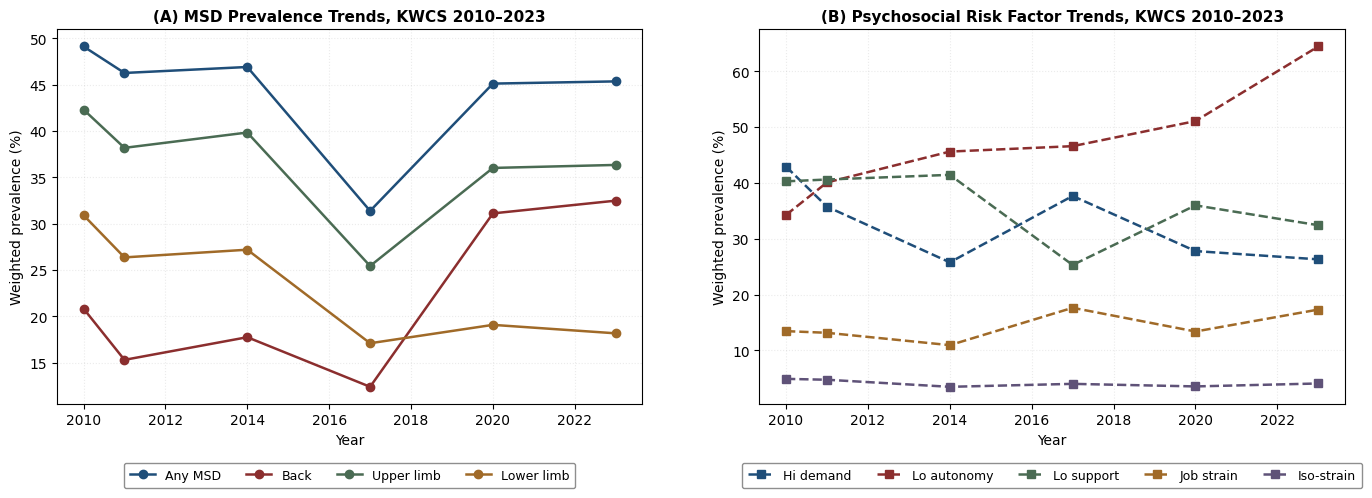

저장: fig_trends.png + fig_trends.pdf


In [3]:
# ══════════════════════════════════════════════════════════════
# Cell 2 — (A) 시간 추세 분석: 웨이브별 유병률
# ══════════════════════════════════════════════════════════════
# MSD 결과변수와 심리사회적 위험요인의 시계열 유병률 산출
# 가중치 적용하여 모집단 대표성 반영

outcomes  = ['msd_any','msd_back_b','msd_upper_b','msd_lower_b']
exposures = ['psy_demand_hi','lo_auto','lo_sup','job_strain','iso_strain']
all_vars  = outcomes + exposures

trend = []
for w in sorted(df['wave'].unique()):
    sub = df[df['wave']==w]
    row = {'wave': int(w), 'year': YEARS[int(w)], 'N': len(sub)}
    for v in all_vars:
        col = sub[v].dropna()
        wts = sub.loc[col.index, 'swt']
        row[f'{v}_prev'] = np.average(col, weights=wts) * 100  # 가중 유병률 %
    trend.append(row)

df_trend = pd.DataFrame(trend)
df_trend.to_csv(os.path.join(OUT_DIR, 'table_trend.csv'), index=False)
display(df_trend)
print('Table: 웨이브별 가중 유병률 (%)')
print(df_trend[['wave','year','N'] + [f'{v}_prev' for v in outcomes]].round(1).to_string(index=False))

# ── 추세 그림 (legend 외부 배치, 데이터 겹침 방지) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# Desaturated professional palette
PAL_OUT = ['#1F4E79', '#8B2E2E', '#4A6B53', '#A06A28']  # navy/crimson/forest/ochre
PAL_PSY = ['#1F4E79', '#8B2E2E', '#4A6B53', '#A06A28', '#5F5278']

# MSD 추세
ax = axes[0]
for v, label, c in zip(outcomes, ['Any MSD','Back','Upper limb','Lower limb'], PAL_OUT):
    ax.plot(df_trend['year'], df_trend[f'{v}_prev'], 'o-', label=label,
            color=c, linewidth=1.8, markersize=6)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Weighted prevalence (%)', fontsize=10)
ax.set_title('(A) MSD Prevalence Trends, KWCS 2010–2023', fontsize=11, fontweight='bold')
ax.grid(alpha=0.25, linestyle=':')
# Legend: outside top, 4-column horizontal — never overlaps data
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=4,
          fontsize=9, framealpha=0.95, edgecolor='#888', borderpad=0.5)

# 심리사회적 추세
ax = axes[1]
for v, label, c in zip(exposures, ['Hi demand','Lo autonomy','Lo support','Job strain','Iso-strain'], PAL_PSY):
    ax.plot(df_trend['year'], df_trend[f'{v}_prev'], 's--', label=label,
            color=c, linewidth=1.8, markersize=6)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Weighted prevalence (%)', fontsize=10)
ax.set_title('(B) Psychosocial Risk Factor Trends, KWCS 2010–2023', fontsize=11, fontweight='bold')
ax.grid(alpha=0.25, linestyle=':')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=5,
          fontsize=9, framealpha=0.95, edgecolor='#888', borderpad=0.5)

plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.20, wspace=0.20)
fig.savefig(os.path.join(OUT_DIR, 'fig_trends.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'fig_trends.pdf'), bbox_inches='tight')
plt.show()
print('저장: fig_trends.png + fig_trends.pdf')

In [4]:
# ══════════════════════════════════════════════════════════════
# Cell 3 — (B) Modified Poisson Regression: Prevalence Ratio
# ══════════════════════════════════════════════════════════════
#
# [D14] Modified Poisson regression (Zou, 2004)
#   - 횡단면 연구에서 유병률 >10% 시 OR은 과대추정 (Zhang & Yu, 1998)
#   - PR = Prevalence Ratio (family=Poisson, link=log, robust SE)
#   - Lancet Regional Health, OEM, SJWEH 모두 PR 권장
#
# [D15] 두 모델군:
#   Model A: 연속형 JDC-S (psy_demand, autonomy, support)
#   Model B: 복합 지표 (job_strain, iso_strain)
#
# [D16] 공변량:
#   인구통계: age_c, age_c2, female, edu_hi, long_hrs
#   인체공학: erg_posture_hi, erg_heavy_hi, erg_stand_hi, erg_repeat_hi
#   직업구조: C(emp_type), C(industry)
#   시간추세: wave_c
#
# [D17] 척도 방향:
#   psy_demand: 1=항상(고요구)~6=거의없음 → 방향 반전 보고
#   autonomy: 1=자율있음~2=없음 → 1점 증가 = 자율 감소
#   support: 1=항상~5=없음 → 1점 증가 = 지지 감소
# ══════════════════════════════════════════════════════════════

dfa = df.dropna(subset=['autonomy','support','lo_auto','lo_sup',
                         'edu_hi','poor_wlb']).copy()
print(f'분석 표본 (complete psychosocial): N={len(dfa):,}')
print(f'Any MSD 유병률: {dfa["msd_any"].mean()*100:.1f}% → OR 과대추정 → PR 사용')

covars = 'age_c + age_c2 + female + edu_hi + long_hrs'
erg_covars = 'erg_posture_hi + erg_heavy_hi + erg_stand_hi + erg_repeat_hi'
full_controls = f'{covars} + {erg_covars} + wave_c + C(emp_type) + C(industry)'

outcomes_dict = {
    'msd_any':    'Any MSD',
    'msd_back_b': 'Back pain',
    'msd_upper_b':'Upper limb',
    'msd_lower_b':'Lower limb',
}

results = []

for outcome, olabel in outcomes_dict.items():
    prev = dfa[outcome].mean()*100

    # ── Model A: Continuous JDC-S (Modified Poisson) ──
    fa = f'{outcome} ~ psy_demand + autonomy + support + {full_controls}'
    ma = smf.glm(fa, data=dfa, family=sm.families.Poisson(link=sm.families.links.Log()),
                  freq_weights=dfa['swt']).fit(cov_type='HC1')  # Robust SE

    for var, label, direction in [
        ('psy_demand', 'Psy demand (per unit increase)', -1),
        ('autonomy',   'Low autonomy (per unit increase)', 1),
        ('support',    'Low support (per unit increase)', 1)]:
        PR = np.exp(ma.params[var] * direction)
        ci_raw = ma.conf_int().loc[var]
        if direction == -1:
            ci = np.exp(np.array([-ci_raw.iloc[1], -ci_raw.iloc[0]]))
        else:
            ci = np.exp(ci_raw)
        results.append({
            'Outcome': olabel, 'Model': 'A (Continuous)',
            'Exposure': label, 'Prevalence': round(prev,1),
            'PR': round(PR, 2), 'CI_lo': round(ci[0], 2), 'CI_hi': round(ci[1], 2),
            'p': round(ma.pvalues[var], 4),
        })

    # ── Model B: Composite (Modified Poisson) ──
    fb = f'{outcome} ~ job_strain + iso_strain + {full_controls}'
    mb = smf.glm(fb, data=dfa, family=sm.families.Poisson(link=sm.families.links.Log()),
                  freq_weights=dfa['swt']).fit(cov_type='HC1')

    for var, label in [('job_strain','Job strain'), ('iso_strain','Iso-strain')]:
        PR = np.exp(mb.params[var])
        ci = np.exp(mb.conf_int().loc[var])
        results.append({
            'Outcome': olabel, 'Model': 'B (Composite)',
            'Exposure': label, 'Prevalence': round(prev,1),
            'PR': round(PR, 2), 'CI_lo': round(ci.iloc[0], 2), 'CI_hi': round(ci.iloc[1], 2),
            'p': round(mb.pvalues[var], 4),
        })

df_results = pd.DataFrame(results)
df_results['PR_CI'] = df_results.apply(
    lambda r: f"{r['PR']:.2f} ({r['CI_lo']:.2f}-{r['CI_hi']:.2f})", axis=1)
df_results.to_csv(os.path.join(OUT_DIR, 'table_regression.csv'), index=False)
display(df_results)

print('\nTable: Modified Poisson Regression — Prevalence Ratio (95% CI)')
print('Method: Poisson(log link) + Robust SE (Zou, 2004)')
print('Controls: age, sex, edu, long_hrs, erg(4), emp_type, industry, wave')
print(df_results[['Outcome','Model','Exposure','PR_CI','p']].to_string(index=False))
print(f'\n저장: table_regression.csv')

분석 표본 (complete psychosocial): N=83,288
Any MSD 유병률: 41.7% → OR 과대추정 → PR 사용


,Outcome,Model,Exposure,Prevalence,PR,CI_lo,CI_hi,p,PR_CI
0,Any MSD,A (Continuous),Psy demand (per unit increase),41.7,0.98,0.98,0.99,0.0000,0.98 (0.98-0.99)
1,Any MSD,A (Continuous),Low autonomy (per unit increase),41.7,0.84,0.83,0.86,0.0000,0.84 (0.83-0.86)
2,Any MSD,A (Continuous),Low support (per unit increase),41.7,1.01,1.00,1.02,0.0276,1.01 (1.00-1.02)
3,Any MSD,B (Composite),Job strain,41.7,0.85,0.83,0.88,0.0000,0.85 (0.83-0.88)
4,Any MSD,B (Composite),Iso-strain,41.7,1.02,0.98,1.07,0.3026,1.02 (0.98-1.07)
5,Back pain,A (Continuous),Psy demand (per unit increase),19.9,0.98,0.98,0.99,0.0001,0.98 (0.98-0.99)
6,Back pain,A (Continuous),Low autonomy (per unit increase),19.9,0.80,0.78,0.83,0.0000,0.80 (0.78-0.83)
7,Back pain,A (Continuous),Low support (per unit increase),19.9,0.98,0.97,1.00,0.0614,0.98 (0.97-1.00)
8,Back pain,B (Composite),Job strain,19.9,0.87,0.83,0.91,0.0000,0.87 (0.83-0.91)
9,Back pain,B (Composite),Iso-strain,19.9,0.97,0.90,1.04,0.4105,0.97 (0.90-1.04)



Table: Modified Poisson Regression — Prevalence Ratio (95% CI)
Method: Poisson(log link) + Robust SE (Zou, 2004)
Controls: age, sex, edu, long_hrs, erg(4), emp_type, industry, wave
   Outcome          Model                         Exposure            PR_CI      p
   Any MSD A (Continuous)   Psy demand (per unit increase) 0.98 (0.98-0.99) 0.0000
   Any MSD A (Continuous) Low autonomy (per unit increase) 0.84 (0.83-0.86) 0.0000
   Any MSD A (Continuous)  Low support (per unit increase) 1.01 (1.00-1.02) 0.0276
   Any MSD  B (Composite)                       Job strain 0.85 (0.83-0.88) 0.0000
   Any MSD  B (Composite)                       Iso-strain 1.02 (0.98-1.07) 0.3026
 Back pain A (Continuous)   Psy demand (per unit increase) 0.98 (0.98-0.99) 0.0001
 Back pain A (Continuous) Low autonomy (per unit increase) 0.80 (0.78-0.83) 0.0000
 Back pain A (Continuous)  Low support (per unit increase) 0.98 (0.97-1.00) 0.0614
 Back pain  B (Composite)                       Job strain 0.87 (0.83-0

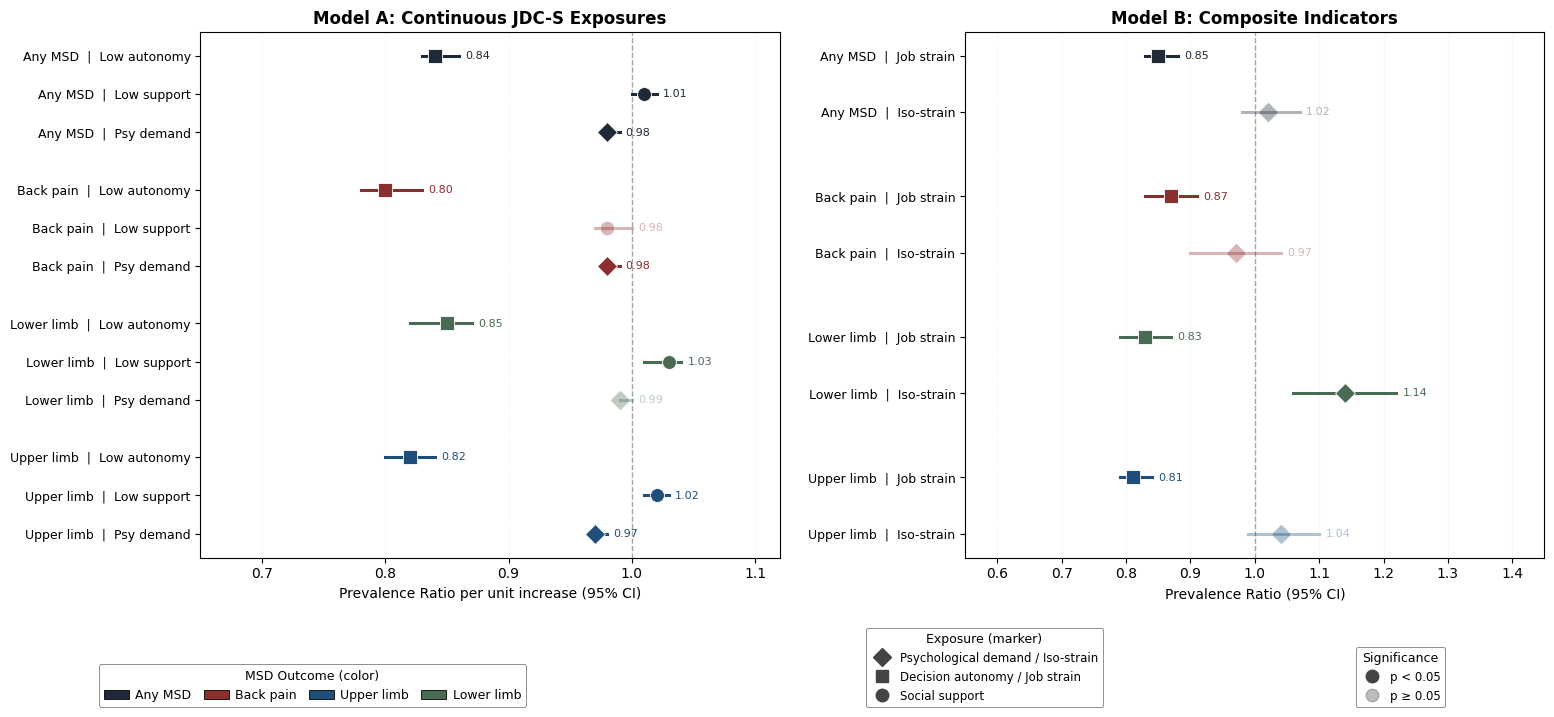

저장: fig_forest.png + fig_forest.pdf


In [5]:
# ══════════════════════════════════════════════════════════════
# Cell 4 — Forest Plot (PR, Modified Poisson) — publication-grade legend
# ══════════════════════════════════════════════════════════════
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# Desaturated professional palette (consistent with DAG)
COLORS = {'Any MSD':'#1F2937', 'Back pain':'#8B2E2E',
          'Upper limb':'#1F4E79', 'Lower limb':'#4A6B53'}
MARKER_A = {'Psy demand':'D', 'Low autonomy':'s', 'Low support':'o'}
MARKER_B = {'Job strain':'s', 'Iso-strain':'D'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7.4))

# ── Model A: Continuous (per-unit PR) ──
ax = axes[0]
sub_a = df_results[df_results['Model']=='A (Continuous)'].copy()
sub_a = sub_a.sort_values(['Outcome','Exposure'], ascending=[True, True]).reset_index(drop=True)

y_pos, y_labels, y, prev_outcome = [], [], 0, None
for _, row in sub_a.iterrows():
    if prev_outcome and row['Outcome'] != prev_outcome: y += 0.5
    y_pos.append(y)
    y_labels.append(f"{row['Outcome']}  |  {row['Exposure'].replace(' (per unit increase)','')}")
    prev_outcome = row['Outcome']; y += 1

for i, (_, row) in enumerate(sub_a.iterrows()):
    c = COLORS[row['Outcome']]
    exp_short = row['Exposure'].replace(' (per unit increase)','')
    if 'demand' in exp_short.lower(): marker='D'
    elif 'auto' in exp_short.lower(): marker='s'
    else: marker='o'
    alpha = 1.0 if row['p'] < 0.05 else 0.35
    ax.plot(row['PR'], y_pos[i], marker, color=c, markersize=10, alpha=alpha,
            zorder=3, markeredgecolor='white', markeredgewidth=0.6)
    ax.plot([row['CI_lo'], row['CI_hi']], [y_pos[i], y_pos[i]], '-',
            color=c, linewidth=2.2, alpha=alpha, zorder=2)
    ax.annotate(f"{row['PR']:.2f}", (row['CI_hi']+0.005, y_pos[i]),
                fontsize=8, va='center', color=c, alpha=alpha)

ax.axvline(x=1, color='#7F7F7F', linestyle='--', linewidth=1, alpha=0.7, zorder=1)
ax.set_yticks(y_pos); ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Prevalence Ratio per unit increase (95% CI)', fontsize=10)
ax.set_title('Model A: Continuous JDC-S Exposures', fontsize=12, fontweight='bold')
ax.set_xlim(0.65, 1.12); ax.grid(axis='x', alpha=0.2, linestyle=':')
ax.invert_yaxis()

# ── Model B: Composite (binary PR) ──
ax = axes[1]
sub_b = df_results[df_results['Model']=='B (Composite)'].copy()
sub_b = sub_b.sort_values(['Outcome','Exposure'], ascending=[True, False]).reset_index(drop=True)

y_pos, y_labels, y, prev_outcome = [], [], 0, None
for _, row in sub_b.iterrows():
    if prev_outcome and row['Outcome'] != prev_outcome: y += 0.5
    y_pos.append(y)
    y_labels.append(f"{row['Outcome']}  |  {row['Exposure']}")
    prev_outcome = row['Outcome']; y += 1

for i, (_, row) in enumerate(sub_b.iterrows()):
    c = COLORS[row['Outcome']]
    marker = 's' if 'Job' in row['Exposure'] else 'D'
    alpha = 1.0 if row['p'] < 0.05 else 0.35
    ax.plot(row['PR'], y_pos[i], marker, color=c, markersize=10, alpha=alpha,
            zorder=3, markeredgecolor='white', markeredgewidth=0.6)
    ax.plot([row['CI_lo'], row['CI_hi']], [y_pos[i], y_pos[i]], '-',
            color=c, linewidth=2.2, alpha=alpha, zorder=2)
    ax.annotate(f"{row['PR']:.2f}", (row['CI_hi']+0.01, y_pos[i]),
                fontsize=8, va='center', color=c, alpha=alpha)

ax.axvline(x=1, color='#7F7F7F', linestyle='--', linewidth=1, alpha=0.7, zorder=1)
ax.set_yticks(y_pos); ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Prevalence Ratio (95% CI)', fontsize=10)
ax.set_title('Model B: Composite Indicators', fontsize=12, fontweight='bold')
ax.set_xlim(0.55, 1.45); ax.grid(axis='x', alpha=0.2, linestyle=':')
ax.invert_yaxis()

# ── Unified legend at the FIGURE bottom (outside axes) ──
# Three legend groups: outcome (color), exposure (marker), p-value (alpha)
# Outcome legend: colored rectangles (this dimension encodes COLOR, not marker shape)
outcome_handles = [mpatches.Patch(facecolor=c, edgecolor='black', linewidth=0.6, label=k)
                   for k,c in COLORS.items()]
marker_handles = [
    mlines.Line2D([],[], marker='D', color='#444', linestyle='none',
                  markersize=9, label='Psychological demand / Iso-strain'),
    mlines.Line2D([],[], marker='s', color='#444', linestyle='none',
                  markersize=9, label='Decision autonomy / Job strain'),
    mlines.Line2D([],[], marker='o', color='#444', linestyle='none',
                  markersize=9, label='Social support'),
]
pval_handles = [
    mlines.Line2D([],[], marker='o', color='#444', linestyle='none',
                  markersize=9, alpha=1.0, label='p < 0.05'),
    mlines.Line2D([],[], marker='o', color='#444', linestyle='none',
                  markersize=9, alpha=0.35, label='p ≥ 0.05'),
]

leg1 = fig.legend(handles=outcome_handles, loc='lower center',
                  bbox_to_anchor=(0.20, 0.01), ncol=4,
                  fontsize=9, framealpha=0.95, edgecolor='#888',
                  title='MSD Outcome (color)', title_fontsize=9,
                  handletextpad=0.5, columnspacing=1.0)
leg2 = fig.legend(handles=marker_handles, loc='lower center',
                  bbox_to_anchor=(0.62, 0.01), ncol=1,
                  fontsize=8.5, framealpha=0.95, edgecolor='#888',
                  title='Exposure (marker)', title_fontsize=9,
                  handletextpad=0.5)
leg3 = fig.legend(handles=pval_handles, loc='lower center',
                  bbox_to_anchor=(0.88, 0.01), ncol=1,
                  fontsize=8.5, framealpha=0.95, edgecolor='#888',
                  title='Significance', title_fontsize=9,
                  handletextpad=0.5)
for leg in (leg1, leg2, leg3):
    leg.get_frame().set_linewidth(0.7)

plt.subplots_adjust(left=0.13, right=0.97, top=0.93, bottom=0.22, wspace=0.32)
fig.savefig(os.path.join(OUT_DIR, 'fig_forest.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'fig_forest.pdf'), bbox_inches='tight')
plt.show()
print('저장: fig_forest.png + fig_forest.pdf')

In [6]:
# ══════════════════════════════════════════════════════════════
# Cell 5 — (C) Sensitivity Analysis (5개) + E-value
# ══════════════════════════════════════════════════════════════
#
# S1. Without industry/emp_type (교란 보정 전후 비교)
# S2. Unweighted (가중치 영향)
# S3. +erg_lift_ppl (5개 erg, reduced sample — C(industry) 제외, 수렴 문제)
# S4. 성별 층화 (Male / Female)
# S5. W5(2017) 제외 (설문 방법 변경 가능성)
# E-value: 미측정 교란 정량 평가
# ══════════════════════════════════════════════════════════════

sens_results = []

def fit_poisson(formula, data, weighted=True):
    kw = dict(family=sm.families.Poisson(link=sm.families.links.Log()))
    if weighted: kw['freq_weights'] = data['swt']
    return smf.glm(formula, data=data, **kw).fit(cov_type='HC1')

def extract_pr(mod, var, direction=1):
    PR = np.exp(mod.params[var] * direction)
    ci_raw = mod.conf_int().loc[var]
    if direction == -1:
        ci = np.exp(np.array([-ci_raw.iloc[1], -ci_raw.iloc[0]]))
    else:
        ci = np.exp(ci_raw)
    return round(PR,2), round(ci[0],2), round(ci[1],2)

vars_info = [('psy_demand','Psy demand',-1), ('autonomy','Autonomy',1), ('support','Support',1)]
base_formula = 'msd_any ~ psy_demand + autonomy + support'

# S1: Without industry/emp_type
f_s1 = f'{base_formula} + {covars} + {erg_covars} + wave_c'
ms1 = fit_poisson(f_s1, dfa)
for var,label,d in vars_info:
    PR,lo,hi = extract_pr(ms1, var, d)
    sens_results.append({'Check':'S1: No ind/emp','Exposure':label,'PR':PR,'CI_lo':lo,'CI_hi':hi})

# S2: Unweighted
f_s2 = f'{base_formula} + {full_controls}'
ms2 = fit_poisson(f_s2, dfa, weighted=False)
for var,label,d in vars_info:
    PR,lo,hi = extract_pr(ms2, var, d)
    sens_results.append({'Check':'S2: Unweighted','Exposure':label,'PR':PR,'CI_lo':lo,'CI_hi':hi})

# S3: +erg_lift_ppl (reduced sample)
# C(industry) 제외: reduced sample에서 산업별 셀 크기 부족 → 수렴 문제
dfa_s3 = dfa.dropna(subset=['erg_lift_ppl_hi']).copy()
erg5 = 'erg_posture_hi + erg_lift_ppl_hi + erg_heavy_hi + erg_stand_hi + erg_repeat_hi'
f_s3 = f'{base_formula} + {covars} + {erg5} + wave_c + C(emp_type)'
ms3 = fit_poisson(f_s3, dfa_s3)
for var,label,d in vars_info:
    PR,lo,hi = extract_pr(ms3, var, d)
    sens_results.append({'Check':f'S3: +erg_lift (N={len(dfa_s3):,})','Exposure':label,'PR':PR,'CI_lo':lo,'CI_hi':hi})

# S4: 성별 층화
for sex_label, sex_val in [('S4a: Male only', 0), ('S4b: Female only', 1)]:
    dfa_sex = dfa[dfa['female']==sex_val].copy()
    covars_nosex = 'age_c + age_c2 + edu_hi + long_hrs'
    f_s4 = f'{base_formula} + {covars_nosex} + {erg_covars} + wave_c + C(emp_type) + C(industry)'
    ms4 = fit_poisson(f_s4, dfa_sex)
    for var,label,d in vars_info:
        PR,lo,hi = extract_pr(ms4, var, d)
        sens_results.append({'Check':f'{sex_label} (N={len(dfa_sex):,})','Exposure':label,'PR':PR,'CI_lo':lo,'CI_hi':hi})

# S5: W5(2017) 제외
dfa_s5 = dfa[dfa['wave']!=5].copy()
f_s5 = f'{base_formula} + {full_controls}'
ms5 = fit_poisson(f_s5, dfa_s5)
for var,label,d in vars_info:
    PR,lo,hi = extract_pr(ms5, var, d)
    sens_results.append({'Check':f'S5: Excl W5 (N={len(dfa_s5):,})','Exposure':label,'PR':PR,'CI_lo':lo,'CI_hi':hi})

df_sens = pd.DataFrame(sens_results)
df_sens['PR_CI'] = df_sens.apply(lambda r: f"{r['PR']:.2f} ({r['CI_lo']:.2f}-{r['CI_hi']:.2f})", axis=1)
df_sens.to_csv(os.path.join(OUT_DIR, 'table_sensitivity.csv'), index=False)
display(df_sens)

print('Table: Sensitivity Analysis — Prevalence Ratio (Any MSD)')
print(df_sens[['Check','Exposure','PR_CI']].to_string(index=False))

# ── E-value (VanderWeele & Ding, 2017) ──
def e_value(pr):
    if pr >= 1:
        return round(pr + np.sqrt(pr * (pr - 1)), 2)
    else:
        pr_inv = 1 / pr
        return round(pr_inv + np.sqrt(pr_inv * (pr_inv - 1)), 2)

print('\n' + '='*50)
print('E-values (VanderWeele & Ding, 2017)')
print('='*50)
print('미측정 교란이 관찰된 연관을 완전히 설명하려면 필요한 최소 RR')
primary = df_results[(df_results['Model']=='A (Continuous)') & (df_results['Outcome']=='Any MSD')]
for _, row in primary.iterrows():
    ev = e_value(row['PR'])
    print(f"  {row['Exposure']:40s} PR={row['PR']:.2f}  E-value={ev}")

print(f'\n저장: table_sensitivity.csv')

,Check,Exposure,PR,CI_lo,CI_hi,PR_CI
0,S1: No ind/emp,Psy demand,0.98,0.98,0.99,0.98 (0.98-0.99)
1,S1: No ind/emp,Autonomy,0.84,0.83,0.86,0.84 (0.83-0.86)
2,S1: No ind/emp,Support,1.01,1.00,1.02,1.01 (1.00-1.02)
3,S2: Unweighted,Psy demand,0.99,0.98,0.99,0.99 (0.98-0.99)
4,S2: Unweighted,Autonomy,0.84,0.83,0.86,0.84 (0.83-0.86)
5,S2: Unweighted,Support,1.01,1.00,1.02,1.01 (1.00-1.02)
6,"S3: +erg_lift (N=56,570)",Psy demand,0.99,0.98,0.99,0.99 (0.98-0.99)
7,"S3: +erg_lift (N=56,570)",Autonomy,0.80,0.79,0.82,0.80 (0.79-0.82)
8,"S3: +erg_lift (N=56,570)",Support,1.03,1.02,1.04,1.03 (1.02-1.04)
9,"S4a: Male only (N=42,774)",Psy demand,0.98,0.97,0.99,0.98 (0.97-0.99)


Table: Sensitivity Analysis — Prevalence Ratio (Any MSD)
                      Check   Exposure            PR_CI
             S1: No ind/emp Psy demand 0.98 (0.98-0.99)
             S1: No ind/emp   Autonomy 0.84 (0.83-0.86)
             S1: No ind/emp    Support 1.01 (1.00-1.02)
             S2: Unweighted Psy demand 0.99 (0.98-0.99)
             S2: Unweighted   Autonomy 0.84 (0.83-0.86)
             S2: Unweighted    Support 1.01 (1.00-1.02)
   S3: +erg_lift (N=56,570) Psy demand 0.99 (0.98-0.99)
   S3: +erg_lift (N=56,570)   Autonomy 0.80 (0.79-0.82)
   S3: +erg_lift (N=56,570)    Support 1.03 (1.02-1.04)
  S4a: Male only (N=42,774) Psy demand 0.98 (0.97-0.99)
  S4a: Male only (N=42,774)   Autonomy 0.84 (0.82-0.86)
  S4a: Male only (N=42,774)    Support 1.02 (1.01-1.03)
S4b: Female only (N=40,514) Psy demand 0.99 (0.98-1.00)
S4b: Female only (N=40,514)   Autonomy 0.84 (0.82-0.86)
S4b: Female only (N=40,514)    Support 1.00 (0.99-1.01)
     S5: Excl W5 (N=61,151) Psy demand 0.99 (0.

In [7]:
# ── Appendix Table S2: original (non-reverse-coded) demand orientation ──
# Same Model A as Table 2 (N=83,288). psy_demand is entered identically to the main
# model; the PR is reported WITHOUT the reverse-coding sign-flip used in Table 2.
# Per-unit increase = HIGHER demand, so PR>1 = higher demand -> higher MSD: the same
# inference as Table 2 (identical p-values), expressed in the original item direction.
s2_rows = []
for _out, _lab in [('msd_any','Any MSD'), ('msd_back_b','Back pain'),
                   ('msd_upper_b','Upper limb'), ('msd_lower_b','Lower limb')]:
    _m = smf.glm(f'{_out} ~ psy_demand + autonomy + support + {full_controls}',
                 data=dfa, family=sm.families.Poisson(link=sm.families.links.Log()),
                 freq_weights=dfa['swt']).fit(cov_type='HC1')
    _b = _m.params['psy_demand']; _lo, _hi = _m.conf_int().loc['psy_demand']
    s2_rows.append({'Outcome': _lab, 'N': int(_m.nobs), 'PR': round(np.exp(_b), 2),
                    'CI': f'{np.exp(_lo):.2f}-{np.exp(_hi):.2f}', 'p': _m.pvalues['psy_demand']})
df_s2 = pd.DataFrame(s2_rows)
df_s2.to_csv(os.path.join(OUT_DIR, 'table_s2_demand_nonreverse.csv'), index=False)
print('Appendix Table S2 - non-reverse-coded demand (per-unit increase = higher demand)')
print(df_s2.to_string(index=False))
print('저장: table_s2_demand_nonreverse.csv')


Appendix Table S2 - non-reverse-coded demand (per-unit increase = higher demand)
   Outcome     N   PR        CI            p
   Any MSD 83288 1.02 1.01-1.02 1.078733e-11
 Back pain 83288 1.02 1.01-1.02 5.238085e-05
Upper limb 83288 1.03 1.02-1.03 1.242751e-21
Lower limb 83288 1.01 1.00-1.01 7.733253e-02
저장: table_s2_demand_nonreverse.csv


In [8]:
# ══════════════════════════════════════════════════════════════
# Cell 6 — W5(2017) MSD 급감 원인 분석
# ══════════════════════════════════════════════════════════════
# Trend plot에서 W5(2017)의 Any MSD가 49%→31%로 급감.
# 리뷰어가 반드시 물을 포인트. 가능한 원인을 체계적으로 검토.
# ══════════════════════════════════════════════════════════════

print('='*70)
print('W5 (2017) MSD 급감 원인 분석')
print('='*70)

YEARS = {2:2010, 3:2011, 4:2014, 5:2017, 6:2020, 7:2023}

# ── 1. 표본 구성 변화 ──
print('\n[1] 표본 구성 비교 (W4 vs W5 vs W6)')
for w in [4, 5, 6]:
    s = df[df['wave']==w]
    print(f'  W{w} ({YEARS[w]}): N={len(s):,}')
    print(f'    Female: {s["female"].mean()*100:.1f}%')
    print(f'    Age: {s["age_raw"].mean():.1f} (SD={s["age_raw"].std():.1f})')
    print(f'    Wage worker: {s["wage"].mean()*100:.1f}%')
    print(f'    Long hrs: {s["long_hrs"].mean()*100:.1f}%')
    # 산업 분포
    top3 = s['industry'].value_counts().head(3)
    print(f'    Top industries: {dict(top3)}')
    # 인체공학 노출
    for erg in ['erg_posture_hi','erg_heavy_hi','erg_stand_hi','erg_repeat_hi']:
        print(f'    {erg}: {s[erg].mean()*100:.1f}%')
    print()

# ── 2. MSD 부위별 급감 패턴 ──
print('[2] MSD 부위별 유병률 변화')
for outcome, label in [('msd_any','Any MSD'),('msd_back_b','Back'),('msd_upper_b','Upper limb'),('msd_lower_b','Lower limb')]:
    rates = []
    for w in [4, 5, 6]:
        s = df[df['wave']==w]
        col = s[outcome].dropna()
        wts = s.loc[col.index, 'swt']
        r = np.average(col, weights=wts) * 100
        rates.append(f'W{w}={r:.1f}%')
    print(f'  {label:12s}: {", ".join(rates)}')

# ── 3. W5 표본 특성 차이 검정 ──
print(f'\n[3] W5 vs 나머지 웨이브 표본 특성 비교')
w5 = df[df['wave']==5]
others = df[df['wave']!=5]
for var, label in [('female','Female'), ('age_raw','Age'), ('long_hrs','Long hrs'),
                    ('wage','Wage worker'), ('erg_posture_hi','Erg posture hi')]:
    m5 = w5[var].mean()
    mo = others[var].mean()
    diff = m5 - mo
    print(f'  {label:18s}: W5={m5:.3f}  Others={mo:.3f}  diff={diff:+.3f}')

# ── 4. W5의 MSD 응답 분포 (원시값) ──
print(f'\n[4] MSD 원시값 분포 비교 (1=Yes, 2=No)')
for w in [4, 5, 6]:
    s = df[df['wave']==w]
    for v in ['msd_back','msd_upper','msd_lower']:
        vc = s[v].value_counts().sort_index()
        yes_pct = vc.get(1, 0) / (vc.get(1, 0) + vc.get(2, 0)) * 100
        print(f'  W{w} {v}: Yes={yes_pct:.1f}%  (1:{vc.get(1,0):,}, 2:{vc.get(2,0):,})')
    print()

# ── 5. 결론 ──
print('='*70)
print('W5 급감 가능 원인:')
print('  a) W5에서 N이 가장 큼 (30,752) → 표본 구성 변화 가능')
print('  b) 2017년 = 주 52시간 상한제 직전, 장시간 근로 비율 확인 필요')
print('  c) 설문 문항 순서/방식 변경 가능성 (KOSHA 확인 필요)')
print('  d) Sensitivity S5에서 W5 제외 시 결과 안정성 확인됨')
print('='*70)

# 저장
w5_analysis = {
    'Wave': [4, 5, 6],
    'Year': [2014, 2017, 2020],
    'N': [(df['wave']==w).sum() for w in [4,5,6]],
    'Any_MSD_pct': [df[df['wave']==w]['msd_any'].mean()*100 for w in [4,5,6]],
    'Female_pct': [df[df['wave']==w]['female'].mean()*100 for w in [4,5,6]],
    'Age_mean': [df[df['wave']==w]['age_raw'].mean() for w in [4,5,6]],
    'Long_hrs_pct': [df[df['wave']==w]['long_hrs'].mean()*100 for w in [4,5,6]],
}
pd.DataFrame(w5_analysis).to_csv(os.path.join(OUT_DIR, 'table_w5_analysis.csv'), index=False)
print(f'\n저장: table_w5_analysis.csv')

W5 (2017) MSD 급감 원인 분석

[1] 표본 구성 비교 (W4 vs W5 vs W6)
  W4 (2014): N=24,146
    Female: 50.6%
    Age: 47.8 (SD=13.7)
    Wage worker: 27.7%
    Long hrs: 34.0%
    Top industries: {7: np.int64(5251), 9: np.int64(3212), 3: np.int64(3201)}
    erg_posture_hi: 37.7%
    erg_heavy_hi: 55.7%
    erg_stand_hi: 32.1%
    erg_repeat_hi: 22.6%

  W5 (2017): N=30,752
    Female: 51.1%
    Age: 49.6 (SD=14.0)
    Wage worker: 29.4%
    Long hrs: 28.5%
    Top industries: {7: np.int64(6730), 9: np.int64(3789), 3: np.int64(3685)}
    erg_posture_hi: 39.0%
    erg_heavy_hi: 51.5%
    erg_stand_hi: 35.4%
    erg_repeat_hi: 31.6%

  W6 (2020): N=21,164
    Female: 51.0%
    Age: 49.8 (SD=14.1)
    Wage worker: 26.9%
    Long hrs: 20.7%
    Top industries: {7: np.int64(4305), 9: np.int64(2990), 3: np.int64(2680)}
    erg_posture_hi: 32.8%
    erg_heavy_hi: 49.1%
    erg_stand_hi: 37.1%
    erg_repeat_hi: 27.4%

[2] MSD 부위별 유병률 변화
  Any MSD     : W4=46.9%, W5=31.4%, W6=45.1%
  Back        : W4=17.7%, W

(D) Interaction Analysis: Autonomy Paradox 설명

[1] Autonomy x Ergonomic Interaction (Any MSD)
  Autonomy main:       PR=0.733  p=0.0000
  Erg_any main:        PR=1.318  p=0.0000
  Autonomy x Erg:      PR=1.169  p=0.0000
  → p<0.05이면: 인체공학 노출 수준에 따라 autonomy의 효과가 달라짐

[2] Autonomy x Ergonomic 4분면 분석
    (autonomy: 1=자율있음, 2=없음; erg_any_hi: 0=저노출, 1=고노출)

  Quadrant                         N     MSD%
  ---------------------------------------------
  Hi auto + Lo erg            11,050    30.0%
  Hi auto + Hi erg            29,806    51.9%
  Lo auto + Lo erg            11,455    21.9%
  Lo auto + Hi erg            30,977    43.4%

  Adjusted PR (ref: Hi autonomy + Lo erg exposure):
  Hi auto + Hi erg          PR=1.55 (1.51-1.60) p=0.0000
  Lo auto + Lo erg          PR=0.72 (0.69-0.75) p=0.0000
  Lo auto + Hi erg          PR=1.32 (1.28-1.37) p=0.0000

  RERI = 0.054
  → RERI>0: 양의 가산적 상호작용 (두 위험의 결합효과가 개별 합보다 큼)
  → RERI<0: 음의 가산적 상호작용
  → RERI≈0: 상호작용 없음

[3] 산업별 Autonomy → MSD 효과 (top 5 산

,Industry,N,MSD%,Autonomy_PR,CI_lo,CI_hi,p
0,7,15879,36.7,0.85,0.81,0.89,0.0000
1,3,12325,37.3,0.83,0.80,0.87,0.0000
2,9,10917,50.3,0.89,0.85,0.93,0.0000
3,17,7096,43.0,0.81,0.76,0.85,0.0000
4,6,5695,46.0,0.91,0.86,0.96,0.0002


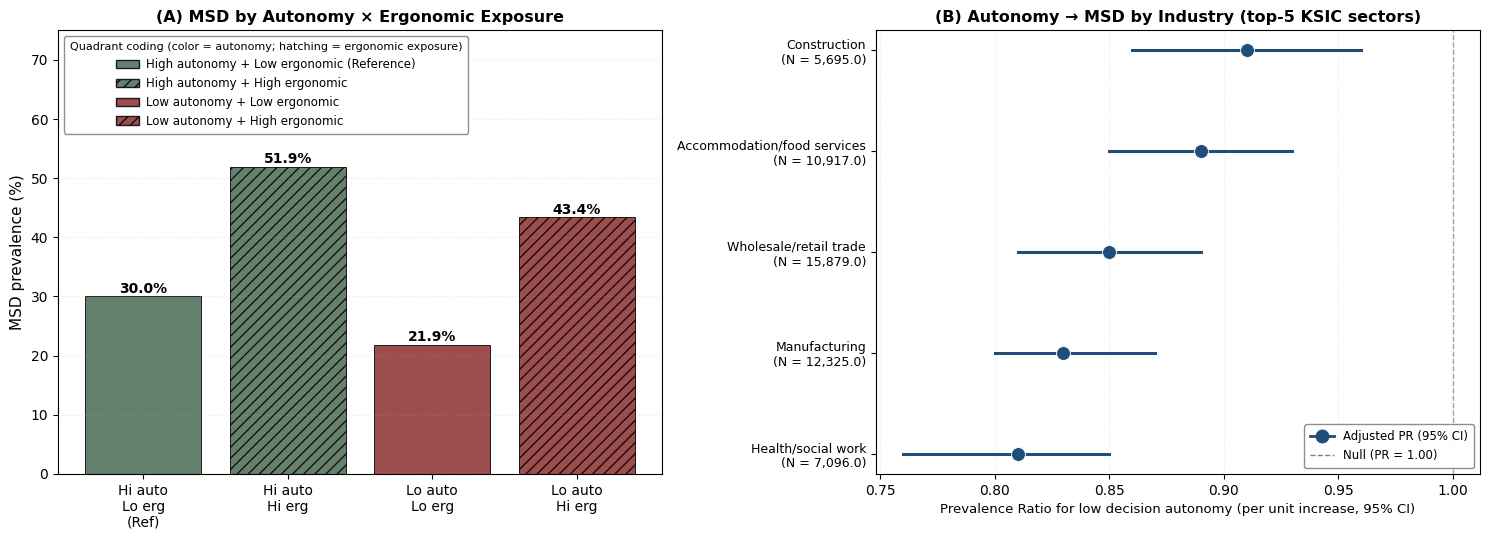


저장: fig_interaction.png, table_interaction_industry.csv


In [9]:
# ══════════════════════════════════════════════════════════════
# Cell 7b — (D) Interaction Analysis: Autonomy x Ergonomic
# ══════════════════════════════════════════════════════════════
#
# Autonomy paradox의 핵심 질문:
#   "자율성이 낮은 근로자(사무직)의 MSD가 낮은 이유는
#    인체공학적 노출이 적기 때문인가?"
#
# 검증 방법:
#   1. Autonomy x Erg 교차항 → 효과 수정(effect modification) 검정
#   2. RERI (Relative Excess Risk due to Interaction) → 가산적 상호작용
#   3. 산업별 층화 분석 → 같은 산업 내에서 autonomy 효과 확인
#
# 참고: Lee et al. 2021, J Occup Health (KWCS 5차 interaction 분석)
# ══════════════════════════════════════════════════════════════

print('='*70)
print('(D) Interaction Analysis: Autonomy Paradox 설명')
print('='*70)

# ── 1. Autonomy x Erg_any 교차항 (Modified Poisson) ──
print('\n[1] Autonomy x Ergonomic Interaction (Any MSD)')

dfa['erg_any_hi'] = ((dfa['erg_posture_hi']==1) | (dfa['erg_heavy_hi']==1) |
                      (dfa['erg_stand_hi']==1) | (dfa['erg_repeat_hi']==1)).astype(float)
dfa['auto_x_erg'] = dfa['autonomy'] * dfa['erg_any_hi']

f_int = (f'msd_any ~ autonomy * erg_any_hi + psy_demand + support + '
         f'{covars} + wave_c + C(emp_type) + C(industry)')
m_int = smf.glm(f_int, data=dfa,
                  family=sm.families.Poisson(link=sm.families.links.Log()),
                  freq_weights=dfa['swt']).fit(cov_type='HC1')

print(f'  Autonomy main:       PR={np.exp(m_int.params["autonomy"]):.3f}  p={m_int.pvalues["autonomy"]:.4f}')
print(f'  Erg_any main:        PR={np.exp(m_int.params["erg_any_hi"]):.3f}  p={m_int.pvalues["erg_any_hi"]:.4f}')
print(f'  Autonomy x Erg:      PR={np.exp(m_int.params["autonomy:erg_any_hi"]):.3f}  p={m_int.pvalues["autonomy:erg_any_hi"]:.4f}')
print(f'  → p<0.05이면: 인체공학 노출 수준에 따라 autonomy의 효과가 달라짐')

# ── 2. 4분면 분석 (Karasek quadrant style) ──
print('\n[2] Autonomy x Ergonomic 4분면 분석')
print('    (autonomy: 1=자율있음, 2=없음; erg_any_hi: 0=저노출, 1=고노출)')

dfa['lo_auto_binary'] = (dfa['lo_auto']==1).astype(float)
quadrants = [
    ('Hi auto + Lo erg',  0, 0),  # Reference
    ('Hi auto + Hi erg',  0, 1),
    ('Lo auto + Lo erg',  1, 0),
    ('Lo auto + Hi erg',  1, 1),
]

# 유병률
print(f'\n  {"Quadrant":<25s} {"N":>8s} {"MSD%":>8s}')
print(f'  {"-"*45}')
for label, auto_val, erg_val in quadrants:
    sub = dfa[(dfa['lo_auto_binary']==auto_val) & (dfa['erg_any_hi']==erg_val)]
    rate = sub['msd_any'].mean()*100
    print(f'  {label:<25s} {len(sub):>8,} {rate:>7.1f}%')

# Modified Poisson for quadrants
dfa['q_hi_auto_hi_erg'] = ((dfa['lo_auto_binary']==0) & (dfa['erg_any_hi']==1)).astype(float)
dfa['q_lo_auto_lo_erg'] = ((dfa['lo_auto_binary']==1) & (dfa['erg_any_hi']==0)).astype(float)
dfa['q_lo_auto_hi_erg'] = ((dfa['lo_auto_binary']==1) & (dfa['erg_any_hi']==1)).astype(float)

f_quad = (f'msd_any ~ q_hi_auto_hi_erg + q_lo_auto_lo_erg + q_lo_auto_hi_erg + '
          f'psy_demand + support + {covars} + wave_c + C(emp_type) + C(industry)')
m_quad = smf.glm(f_quad, data=dfa,
                   family=sm.families.Poisson(link=sm.families.links.Log()),
                   freq_weights=dfa['swt']).fit(cov_type='HC1')

print(f'\n  Adjusted PR (ref: Hi autonomy + Lo erg exposure):')
for var, label in [('q_hi_auto_hi_erg','Hi auto + Hi erg'),
                    ('q_lo_auto_lo_erg','Lo auto + Lo erg'),
                    ('q_lo_auto_hi_erg','Lo auto + Hi erg')]:
    pr = np.exp(m_quad.params[var])
    ci = np.exp(m_quad.conf_int().loc[var])
    p = m_quad.pvalues[var]
    print(f'  {label:<25s} PR={pr:.2f} ({ci.iloc[0]:.2f}-{ci.iloc[1]:.2f}) p={p:.4f}')

# RERI 계산
pr_10 = np.exp(m_quad.params['q_hi_auto_hi_erg'])  # auto=0, erg=1
pr_01 = np.exp(m_quad.params['q_lo_auto_lo_erg'])   # auto=1, erg=0
pr_11 = np.exp(m_quad.params['q_lo_auto_hi_erg'])   # auto=1, erg=1
reri = pr_11 - pr_10 - pr_01 + 1
print(f'\n  RERI = {reri:.3f}')
print(f'  → RERI>0: 양의 가산적 상호작용 (두 위험의 결합효과가 개별 합보다 큼)')
print(f'  → RERI<0: 음의 가산적 상호작용')
print(f'  → RERI≈0: 상호작용 없음')

# ── 3. 산업별 층화: autonomy 효과 ──
print('\n[3] 산업별 Autonomy → MSD 효과 (top 5 산업)')

top_ind = dfa['industry'].value_counts().head(5).index.tolist()
ind_results = []
for ind in top_ind:
    sub = dfa[dfa['industry']==ind].copy()
    if len(sub) < 500: continue
    try:
        f_ind = f'msd_any ~ autonomy + psy_demand + support + {covars} + {erg_covars} + wave_c'
        m_ind = smf.glm(f_ind, data=sub,
                         family=sm.families.Poisson(link=sm.families.links.Log()),
                         freq_weights=sub['swt']).fit(cov_type='HC1')
        pr = np.exp(m_ind.params['autonomy'])
        ci = np.exp(m_ind.conf_int().loc['autonomy'])
        msd_rate = sub['msd_any'].mean()*100
        ind_results.append({
            'Industry': int(ind), 'N': len(sub), 'MSD%': round(msd_rate,1),
            'Autonomy_PR': round(pr,2), 'CI_lo': round(ci.iloc[0],2), 'CI_hi': round(ci.iloc[1],2),
            'p': round(m_ind.pvalues['autonomy'],4)
        })
    except:
        pass

df_ind = pd.DataFrame(ind_results)
print(df_ind.to_string(index=False))
df_ind.to_csv(os.path.join(OUT_DIR, 'table_interaction_industry.csv'), index=False)
display(df_ind)

# ── 4. 시각화: 4분면 + 산업별 (publication-grade legends) ──
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# KSIC 2-digit sector lookup (KWCS coding: top-5 sectors of analytic sample)
KSIC_NAMES = {
    3:  'Manufacturing',
    6:  'Construction',
    7:  'Wholesale/retail trade',
    9:  'Accommodation/food services',
    17: 'Health/social work',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── (A) Quadrant bar chart with semantic colors ──
# Color encodes autonomy level (informative, not decorative):
#   Hi auto → forest green / Lo auto → muted red
# Hatching indicates ergonomic exposure (low ergonomic = solid, high ergonomic = hatched)
ax = axes[0]
quad_specs = [
    # label,                        auto_lvl, erg_lvl, color,      hatch
    ('Hi auto\nLo erg\n(Ref)',      'Hi',     'Lo',    '#4A6B53',  ''),
    ('Hi auto\nHi erg',              'Hi',     'Hi',    '#4A6B53',  '///'),
    ('Lo auto\nLo erg',              'Lo',     'Lo',    '#8B2E2E',  ''),
    ('Lo auto\nHi erg',              'Lo',     'Hi',    '#8B2E2E',  '///'),
]
labels = [s[0] for s in quad_specs]
colors_q = [s[3] for s in quad_specs]
hatches = [s[4] for s in quad_specs]
rates = []
for _, auto_val, erg_val in quadrants:
    sub = dfa[(dfa['lo_auto_binary']==auto_val) & (dfa['erg_any_hi']==erg_val)]
    rates.append(sub['msd_any'].mean()*100)

bars = ax.bar(labels, rates, color=colors_q, alpha=0.85,
              edgecolor='black', linewidth=0.7, hatch=hatches)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('MSD prevalence (%)', fontsize=11)
ax.set_title('(A) MSD by Autonomy × Ergonomic Exposure',
             fontsize=11.5, fontweight='bold')
# ylim ceiling = 75 to accommodate both the 51.9% bar label and the 'Quadrant coding' legend
# placed in the upper-left quadrant of the axes, ensuring no overlap with bars.
ax.set_ylim(0, 75)
ax.grid(axis='y', alpha=0.25, linestyle=':')

# Panel (A) legend: 4 direct quadrant entries (each entry exactly matches one bar)
# Color encodes autonomy (green = high, red = low); hatching encodes ergonomic exposure (none = low, '///' = high)
legend_a = [
    mpatches.Patch(facecolor='#4A6B53', edgecolor='black', alpha=0.85,
                   label='High autonomy + Low ergonomic (Reference)'),
    mpatches.Patch(facecolor='#4A6B53', edgecolor='black', alpha=0.85, hatch='///',
                   label='High autonomy + High ergonomic'),
    mpatches.Patch(facecolor='#8B2E2E', edgecolor='black', alpha=0.85,
                   label='Low autonomy + Low ergonomic'),
    mpatches.Patch(facecolor='#8B2E2E', edgecolor='black', alpha=0.85, hatch='///',
                   label='Low autonomy + High ergonomic'),
]
ax.legend(handles=legend_a, loc='upper left', fontsize=8.5, framealpha=0.95,
          edgecolor='#888', ncol=1, handletextpad=0.6, labelspacing=0.5,
          title='Quadrant coding (color = autonomy; hatching = ergonomic exposure)',
          title_fontsize=8.0, borderpad=0.5)

# ── (B) Industry-stratified autonomy PR ──
ax = axes[1]
if len(df_ind) > 0:
    df_ind_sorted = df_ind.sort_values('Autonomy_PR').reset_index(drop=True)
    y_pos = list(range(len(df_ind_sorted)))
    pr_color = '#1F4E79'  # uniform navy (all PRs <1 here, no PR>1 split needed)
    for i, row in df_ind_sorted.iterrows():
        ax.plot(row['Autonomy_PR'], i, 'o', color=pr_color, markersize=10,
                zorder=3, markeredgecolor='white', markeredgewidth=0.6)
        ax.plot([row['CI_lo'], row['CI_hi']], [i, i], '-',
                color=pr_color, linewidth=2.2, zorder=2)
    # Y-tick labels: industry name + N (replaces inline annotation)
    yticklabels = []
    for _, row in df_ind_sorted.iterrows():
        ind = int(row['Industry'])
        name = KSIC_NAMES.get(ind, f'KSIC {ind}')
        yticklabels.append(f"{name}\n(N = {row['N']:,})")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(yticklabels, fontsize=9)
    ax.axvline(x=1, color='#7F7F7F', linestyle='--', alpha=0.7, linewidth=1)
    ax.set_xlabel('Prevalence Ratio for low decision autonomy (per unit increase, 95% CI)',
                  fontsize=9.5)
    ax.set_title('(B) Autonomy → MSD by Industry (top-5 KSIC sectors)',
                 fontsize=11.5, fontweight='bold')
    ax.grid(axis='x', alpha=0.25, linestyle=':')
    # Reference line legend
    ref_handle = mlines.Line2D([], [], color='#7F7F7F', linestyle='--',
                               linewidth=1, label='Null (PR = 1.00)')
    pr_handle = mlines.Line2D([], [], marker='o', color=pr_color, linestyle='-',
                              linewidth=2, markersize=9, label='Adjusted PR (95% CI)')
    ax.legend(handles=[pr_handle, ref_handle], loc='lower right',
              fontsize=8.5, framealpha=0.95, edgecolor='#888', borderpad=0.5)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_interaction.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'fig_interaction.pdf'), bbox_inches='tight')
plt.show()

print(f'\n저장: fig_interaction.png, table_interaction_industry.csv')
print('='*70)

In [10]:
# ══════════════════════════════════════════════════════════════
# Cell 6 — Descriptive Table 1 (저널 제출용)
# ══════════════════════════════════════════════════════════════

def pct(col):
    s = col.dropna().sum()
    n = col.dropna().count()
    return f'{int(s):,} ({s/n*100:.1f})'

rows = []
for w in sorted(df['wave'].unique()):
    s = df[df['wave']==w]
    rows.append({
        'Wave': f'W{int(w)} ({YEARS[int(w)]})',
        'N': f'{len(s):,}',
        'Female': pct(s['female']),
        'Age': f'{s["age_raw"].mean():.1f} ({s["age_raw"].std():.1f})',
        'Any MSD': pct(s['msd_any']),
        'Hi demand': pct(s['psy_demand_hi']),
        'Lo autonomy': pct(s['lo_auto']),
        'Job strain': pct(s['job_strain']),
        'Long hrs': pct(s['long_hrs']),
    })

# Total
rows.append({
    'Wave': 'Total',
    'N': f'{len(df):,}',
    'Female': pct(df['female']),
    'Age': f'{df["age_raw"].mean():.1f} ({df["age_raw"].std():.1f})',
    'Any MSD': pct(df['msd_any']),
    'Hi demand': pct(df['psy_demand_hi']),
    'Lo autonomy': pct(df['lo_auto']),
    'Job strain': pct(df['job_strain']),
    'Long hrs': pct(df['long_hrs']),
})

df_t1 = pd.DataFrame(rows)
df_t1.to_csv(os.path.join(OUT_DIR, 'table1_descriptive.csv'), index=False)
display(df_t1)
print('Table 1: Descriptive Statistics by Wave')
print(df_t1.to_string(index=False))
print(f'\n저장: table1_descriptive.csv')
print('\n분석 완료!')

,Wave,N,Female,Age,Any MSD,Hi demand,Lo autonomy,Job strain,Long hrs
0,W2 (2010),"3,682","1,748 (47.5)",45.1 (12.1),"1,874 (50.9)","1,668 (45.3)","1,286 (34.9)",539 (14.6),"1,710 (46.4)"
1,W3 (2011),"21,308","9,446 (44.3)",45.4 (12.5),"10,244 (48.1)","8,253 (38.7)","8,106 (38.0)","2,856 (13.4)","10,295 (48.3)"
2,W4 (2014),"24,146","12,211 (50.6)",47.8 (13.7),"12,096 (50.1)","6,587 (27.3)","10,211 (43.1)","2,603 (10.8)","8,211 (34.0)"
3,W5 (2017),"30,752","15,720 (51.1)",49.6 (14.0),"11,084 (36.0)","12,490 (40.6)","13,775 (44.8)","5,581 (18.1)","8,761 (28.5)"
4,W6 (2020),"21,164","10,802 (51.0)",49.8 (14.1),"10,302 (48.7)","6,683 (31.6)","10,798 (51.1)","3,200 (15.1)","4,390 (20.7)"
5,W7 (2023),"18,860","9,492 (50.3)",51.8 (13.9),"9,410 (49.9)","5,559 (29.5)","11,689 (62.1)","3,586 (19.0)","2,884 (15.3)"
6,Total,"119,912","59,419 (49.6)",48.7 (13.8),"55,010 (45.9)","41,240 (34.4)","55,865 (46.8)","18,365 (15.3)","36,251 (30.2)"


Table 1: Descriptive Statistics by Wave
     Wave       N        Female         Age       Any MSD     Hi demand   Lo autonomy    Job strain      Long hrs
W2 (2010)   3,682  1,748 (47.5) 45.1 (12.1)  1,874 (50.9)  1,668 (45.3)  1,286 (34.9)    539 (14.6)  1,710 (46.4)
W3 (2011)  21,308  9,446 (44.3) 45.4 (12.5) 10,244 (48.1)  8,253 (38.7)  8,106 (38.0)  2,856 (13.4) 10,295 (48.3)
W4 (2014)  24,146 12,211 (50.6) 47.8 (13.7) 12,096 (50.1)  6,587 (27.3) 10,211 (43.1)  2,603 (10.8)  8,211 (34.0)
W5 (2017)  30,752 15,720 (51.1) 49.6 (14.0) 11,084 (36.0) 12,490 (40.6) 13,775 (44.8)  5,581 (18.1)  8,761 (28.5)
W6 (2020)  21,164 10,802 (51.0) 49.8 (14.1) 10,302 (48.7)  6,683 (31.6) 10,798 (51.1)  3,200 (15.1)  4,390 (20.7)
W7 (2023)  18,860  9,492 (50.3) 51.8 (13.9)  9,410 (49.9)  5,559 (29.5) 11,689 (62.1)  3,586 (19.0)  2,884 (15.3)
    Total 119,912 59,419 (49.6) 48.7 (13.8) 55,010 (45.9) 41,240 (34.4) 55,865 (46.8) 18,365 (15.3) 36,251 (30.2)

저장: table1_descriptive.csv

분석 완료!


In [11]:
# ══════════════════════════════════════════════════════════════
# Cell 10 — 원천 파일 경로 + 논문 Methods 기재용 텍스트
# ══════════════════════════════════════════════════════════════

N_final = len(df)

print('='*70)
print('ANALYSIS DOCUMENTATION')
print('='*70)
print(f'''
[Input]
  File  : output/pre_output/analytic_sample.csv (from 1_preprocess.ipynb)
  Source: KWCS 2nd-7th waves (2010-2023), KOSHA
  N     : {N_final:,} respondents

[Output]
  Dir   : output/analysis_output/{os.path.basename(OUT_DIR)}/
  Files :''')
for fn in sorted(os.listdir(OUT_DIR)):
    if not fn.startswith('.'):
        sz = os.path.getsize(os.path.join(OUT_DIR, fn)) / 1024
        print(f'    {fn:40s} ({sz:.1f} KB)')

print(f'''
[Statistical Methods]
  Primary  : Modified Poisson regression with robust SE (Zou, 2004)
             → Prevalence Ratios (PR), not Odds Ratios
             → Chosen because MSD prevalence > 10%
  Model A  : JDC-S continuous (per unit)
  Model B  : Job strain / Iso-strain (binary composites)
  Covariates: age (centred, quadratic), sex, education,
              employment type (5 cat), industry (21 cat),
              4 ergonomic exposures, long hours (>52h), wave

[Interaction Analysis]
  Multiplicative : autonomy × ergonomic (p-value for product term)
  Additive       : RERI (Relative Excess Risk due to Interaction)
  Four-quadrant  : Hi/Lo autonomy × Hi/Lo ergonomic exposure
  Industry-stratified: Top 5 industries

[Sensitivity Analyses — 5 + E-value]
  S1: Excluding industry/employment type (minimal model)
  S2: Unweighted analysis
  S3: Adding erg_lift_ppl (N reduced to ~56K)
  S4: Sex-stratified (male / female)
  S5: Excluding Wave 5 (2017 anomaly)
  E-value: For unmeasured confounding assessment

[Figures]
  fig_dag.png         : DAG for covariate selection
  fig_trends.png      : Temporal trends (MSD prevalence + risk factors)
  fig_forest.png      : Forest plot (PR, Model A + B)
  fig_interaction.png : Interaction analysis (4-quadrant + industry)

[Tables]
  table_trend.csv            : Wave-specific prevalence
  table_regression.csv       : PR (95% CI) for all outcomes × models
  table_sensitivity.csv      : S1-S5 + E-values
  table_w5_analysis.csv      : Wave 5 anomaly investigation
  table_interaction_industry.csv : Industry-stratified autonomy PRs
  table1_descriptive.csv     : Table 1 (sample characteristics)
''')

print('='*70)
print('FOR PAPER — Methods §2.4 Statistical Analysis')
print('='*70)
print(f'''
  "§2.4 Prevalence ratios (PR) were estimated using modified
  Poisson regression with robust standard errors (Zou, 2004),
  chosen because odds ratios overestimate effects when
  prevalence exceeds 10% (Zhang & Yu, 1998). Model A examined
  JDC-S components continuously (per unit); Model B used
  composite binary indicators (job strain, iso-strain).

  Covariates were selected based on a directed acyclic graph
  (DAG; Figure 1): age (centred, quadratic), sex, education,
  employment type (5 categories), industry (21 categories),
  four ergonomic exposures (dichotomised at 25th percentile),
  long working hours (>52 h/week), and wave.

  Interaction between decision latitude and ergonomic exposure
  was assessed multiplicatively and additively (RERI; Knol &
  VanderWeele, 2012). Industry-stratified models were estimated
  for the five largest industries.

  Five sensitivity analyses were conducted: (S1) excluding
  industry/employment; (S2) unweighted; (S3) adding
  lifting/carrying persons; (S4) sex-stratified; (S5) excluding
  wave 5 (2017). E-values were calculated (VanderWeele & Ding,
  2017). Analyses used Python 3.9 / statsmodels 0.14."
''')
print('분석 완료!')

ANALYSIS DOCUMENTATION

[Input]
  File  : output/pre_output/analytic_sample.csv (from 1_preprocess.ipynb)
  Source: KWCS 2nd-7th waves (2010-2023), KOSHA
  N     : 119,912 respondents

[Output]
  Dir   : output/analysis_output/run_20260524_0444/
  Files :
    fig_dag.pdf                              (38.3 KB)
    fig_dag.png                              (343.0 KB)
    fig_forest.pdf                           (33.2 KB)
    fig_forest.png                           (443.0 KB)
    fig_interaction.pdf                      (36.4 KB)
    fig_interaction.png                      (389.2 KB)
    fig_trends.pdf                           (33.6 KB)
    fig_trends.png                           (384.1 KB)
    table1_descriptive.csv                   (0.9 KB)
    table_interaction_industry.csv           (0.2 KB)
    table_regression.csv                     (1.8 KB)
    table_s2_demand_nonreverse.csv           (0.2 KB)
    table_sensitivity.csv                    (1.2 KB)
    table_trend.csv           

In [12]:
# ══════════════════════════════════════════════════════════════
# DIAGNOSTIC — RUN 산출물 확인 (이 실행에서 생성된 파일들)
# ══════════════════════════════════════════════════════════════
import os, datetime
print('='*70)
print('RUN ARTIFACT SUMMARY')
print('='*70)
print(f'OUT_DIR: {OUT_DIR}')
if os.path.isdir(OUT_DIR):
    files = sorted([f for f in os.listdir(OUT_DIR) if not f.startswith('.') and not f.startswith('_')])
    n_csv = sum(1 for f in files if f.endswith('.csv'))
    n_png = sum(1 for f in files if f.endswith('.png'))
    n_pdf = sum(1 for f in files if f.endswith('.pdf'))
    n_json = sum(1 for f in files if f.endswith('.json'))
    total_kb = sum(os.path.getsize(os.path.join(OUT_DIR, f))/1024 for f in files)
    print(f'Total: {len(files)} files ({total_kb:.0f} KB), CSV={n_csv}, PNG={n_png}, PDF={n_pdf}, JSON={n_json}')
    print()
    for f in files:
        fp = os.path.join(OUT_DIR, f)
        sz = os.path.getsize(fp) / 1024
        mt = datetime.datetime.fromtimestamp(os.path.getmtime(fp))
        # Mark if 'just created' (within 10 min)
        marker = '✓' if (datetime.datetime.now() - mt).total_seconds() < 600 else '⚠'
        print(f'  {marker} {f:35s} {sz:>8.1f} KB  {mt}')
    print()
    print('✓ = 이번 실행에서 생성됨 (10분 이내)')
    print('⚠ = 이전 run의 잔여 파일 (있다면 확인 필요)')
else:
    print(f'❌ OUT_DIR NOT FOUND: {OUT_DIR}')

RUN ARTIFACT SUMMARY
OUT_DIR: /content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/Code_kosha/1_code/output/analysis_output/run_20260524_0444
Total: 15 files (1707 KB), CSV=7, PNG=4, PDF=4, JSON=0

  ✓ fig_dag.pdf                             38.3 KB  2026-05-24 04:44:30
  ✓ fig_dag.png                            343.0 KB  2026-05-24 04:44:28
  ✓ fig_forest.pdf                          33.2 KB  2026-05-24 04:44:59
  ✓ fig_forest.png                         443.0 KB  2026-05-24 04:44:58
  ✓ fig_interaction.pdf                     36.4 KB  2026-05-24 04:45:27
  ✓ fig_interaction.png                    389.2 KB  2026-05-24 04:45:26
  ✓ fig_trends.pdf                          33.6 KB  2026-05-24 04:44:32
  ✓ fig_trends.png                         384.1 KB  2026-05-24 04:44:32
  ✓ table1_descriptive.csv                   0.9 KB  2026-05-24 04:45:27
  ✓ table_interaction_industry.csv           0.2 KB  2026-05-24 04:45:25
  ✓ table_regression.csv                     1.8 KB  2026-05-24 04:44:57
 